In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
from matplotlib import pyplot as plt

from lmfit.model import load_modelresult


In [2]:
ROOT = Path.cwd()  

sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "py_modules"))

from pipeline_config import MAPS_DIR, FIGS_DIR 
import results_comp
import ci_results_compiler
import plot_fit_params
import list_maps_plots


# Loading files

In [3]:
filelist = "fits_ready/filelist_circles.txt"

with open(filelist, "r", encoding="utf-8") as f:
    names = [line.strip() for line in f if line.strip()]

In [4]:
bundles = {}

for name in names:
    bundles[name] = results_comp.load_line_bundle(
        name, name, MAPS_DIR, read_header=True
    )

In [5]:
#bundles['LVM-30Dor-6563_C0']

In [6]:
dfs_obs  = {name: bundle["obs"]  for name, bundle in bundles.items()}
dfs_fit  = {name: bundle["fit"]  for name, bundle in bundles.items()}
meta_all = {name: bundle["meta"] for name, bundle in bundles.items()}

In [7]:
#meta_all['LVM-30Dor-6563_C0']

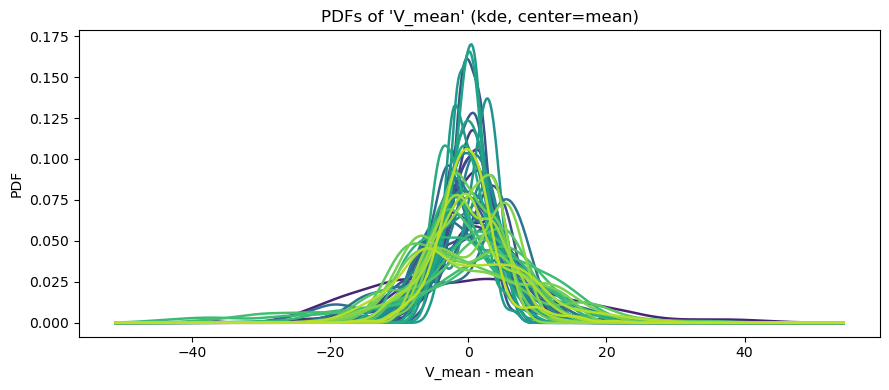

In [8]:
fig, ax, stats_df = list_maps_plots.plot_list_pdfs_circles(
    dfs_obs,
    col="V_mean",
    center="mean",
    method="kde",
    cmap="viridis",
    legend_mode="none",
    annotate=False,
    figsize=(9, 4),
    bw_scale=1.0
)

In [9]:
stats_df

,name,N,mean,std,var,xmin,xmax
0,LVM-30Dor-6563_C0,1449,-1.778236,13.790675,190.182706,-44.892021,49.538967
1,LVM-30Dor-6563_I1,1407,-6.210097,5.529277,30.572907,-20.273308,13.959491
2,LVM-30Dor-6563_I2,1332,-6.330403,4.135695,17.103974,-15.048356,13.430567
3,LVM-30Dor-6563_I3,1456,-3.625136,7.092431,50.302584,-28.051868,21.354507
4,LVM-30Dor-6563_I4,1231,-4.135266,7.593565,57.662231,-23.149562,21.864637
5,LVM-30Dor-6563_I5,1218,-1.494309,4.883698,23.850508,-22.034809,11.972636
6,LVM-30Dor-6563_I6,1329,-0.913235,4.231918,17.909127,-37.090137,14.431522
7,LVM-30Dor-6563_I7,1243,-3.162907,5.304910,28.142075,-19.075231,15.939232
8,LVM-30Dor-6563_I8,1220,-9.411072,7.094624,50.333689,-22.026946,15.420529
9,LVM-30Dor-6563_M1,1404,-4.010726,4.989411,24.894221,-14.864901,9.929145


In [10]:
#dfs_fit['LVM-30Dor-6563']

In [11]:
from astropy.coordinates import SkyCoord
import astropy.units as u
from astropy.wcs import WCS
from astropy.visualization.wcsaxes.patches import SphericalCircle


c0 = SkyCoord.from_name("Tarantula")
fov_deg = 1.0  # Total field of view in degrees (width and height)
pix_scale = 1 / 3600
npix = int(fov_deg / pix_scale)

# Create WCS for TAN projection centered at 'center'
wcs = WCS(naxis=2)
wcs.wcs.ctype = ["RA---TAN", "DEC--TAN"]
wcs.wcs.crval = [c0.ra.deg, c0.dec.deg]
wcs.wcs.crpix = [npix, npix]  # center of your "image"
wcs.wcs.cdelt = [-pix_scale, pix_scale]  # field size / pixel count

In [12]:
name_file = "LVM-30Dor-6563"   # adjust if needed

circles_df = pd.read_csv("fits_ready/circle_catalog.csv")
circles_df["name"] = [f"{name_file}_{lab}" for lab in circles_df["label"]]

In [13]:

circles = []
for _, row in circles_df.iterrows():
    center = SkyCoord(
        ra=row["ra_deg"] * u.deg,
        dec=row["dec_deg"] * u.deg,
        frame="icrs"
    )

    circles.append({
        "name": row["name"],
        "label": row["label"],
        "ring": row["ring"],
        "angle_deg": row["angle_deg"],
        "center": center,
        "ra_deg": row["ra_deg"],
        "dec_deg": row["dec_deg"],
        "radius_arcsec": row["radius_arcsec"],
    })

In [14]:
circles[0]

{'name': 'LVM-30Dor-6563_C0',
 'label': 'C0',
 'ring': 'center',
 'angle_deg': nan,
 'center': <SkyCoord (ICRS): (ra, dec) in deg
     (84.675, -69.1)>,
 'ra_deg': 84.675,
 'dec_deg': -69.1,
 'radius_arcsec': 206.5}

In [15]:
#circles

Text(0.5, 1.0, 'Circle regions')

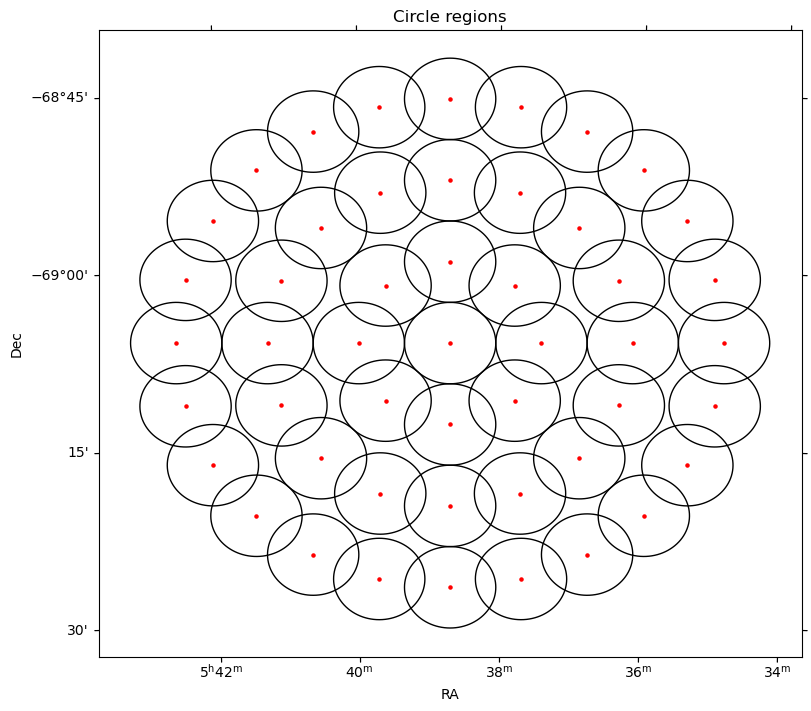

In [16]:
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.visualization.wcsaxes.patches import SphericalCircle

fig = plt.figure(figsize=(8, 7), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

for item in circles:
    # draw center point
    ax.scatter(
        item["ra_deg"],
        item["dec_deg"],
        s=5,
        color="red",
        transform=ax.get_transform("world")
    )

    # draw circle
    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor="black",
        facecolor="none",
        linewidth=1.0,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("Circle regions")

Text(0.5, 1.0, 'Circle regions')

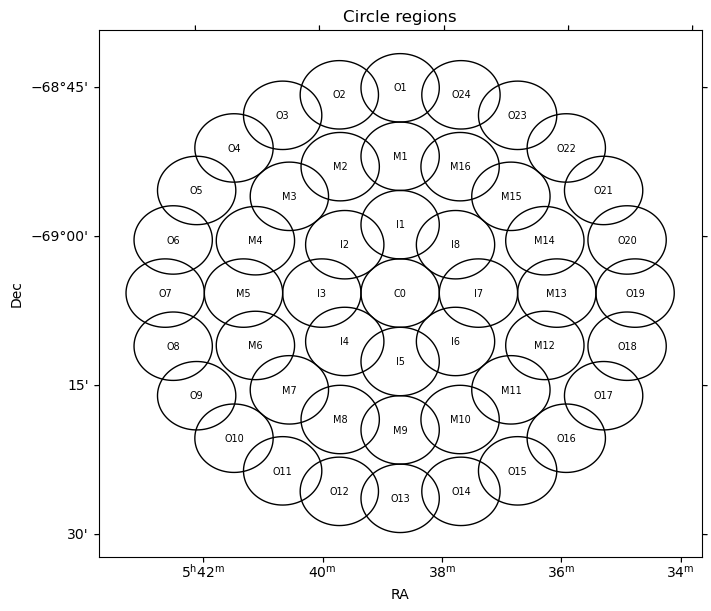

In [17]:
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.visualization.wcsaxes.patches import SphericalCircle

fig = plt.figure(figsize=(7, 6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

# anchor the WCS plot with the circle centers
ra_vals  = [item["ra_deg"] for item in circles]
dec_vals = [item["dec_deg"] for item in circles]

ax.scatter(
    ra_vals,
    dec_vals,
    s=1.0,
    color="white",
    alpha=0.01,
    transform=ax.get_transform("world")
)

for item in circles:
    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor="black",
        facecolor="none",
        linewidth=1,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

    ax.text(
        item["ra_deg"],
        item["dec_deg"],
        item["label"],
        transform=ax.get_transform("world"),
        ha="center",
        va="center",
        fontsize=7,
        color="black"
    )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("Circle regions")

Text(0.5, 1.0, 'sig2 by circle')

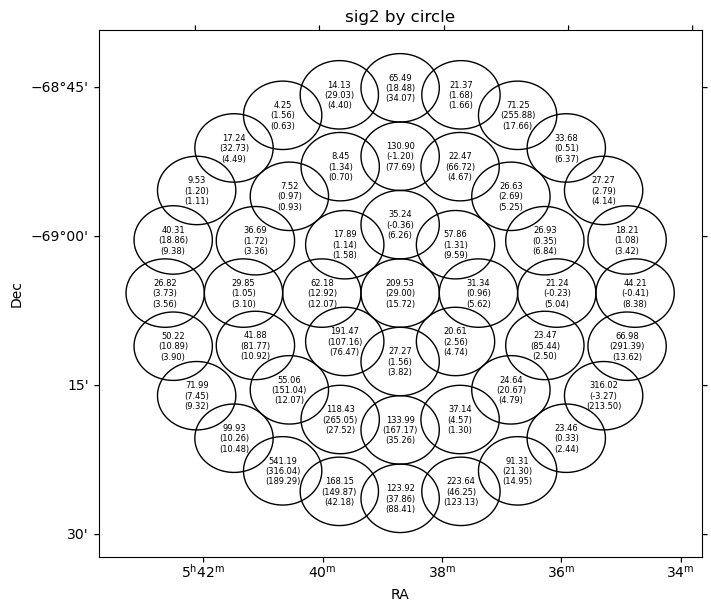

In [18]:
import matplotlib.pyplot as plt
import astropy.units as u
from astropy.visualization.wcsaxes.patches import SphericalCircle

fig = plt.figure(figsize=(7, 6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

# anchor the WCS plot with the circle centers
ra_vals  = [item["ra_deg"] for item in circles]
dec_vals = [item["dec_deg"] for item in circles]

ax.scatter(
    ra_vals,
    dec_vals,
    s=1.0,
    color="white",
    alpha=0.01,
    transform=ax.get_transform("world")
)

for item in circles:
    name = item["name"]
    df_fit = dfs_fit[name]

    vals = df_fit["sig2"].tolist()[:3]
    txt = f"{vals[0]:.2f}\n({vals[1]:.2f})\n({vals[2]:.2f})"

    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor="black",
        facecolor="none",
        linewidth=1,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

    ax.text(
        item["ra_deg"],
        item["dec_deg"],
        txt,
        transform=ax.get_transform("world"),
        ha="center",
        va="center",
        fontsize=6,
        color="black"
    )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("sig2 by circle")

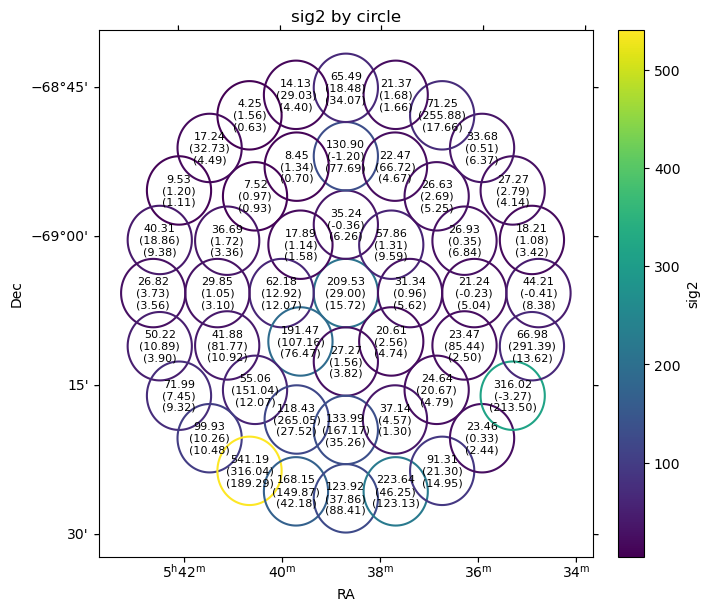

In [19]:
import matplotlib as mpl

fig = plt.figure(figsize=(7, 6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

# anchor the WCS plot with the circle centers
ra_vals  = [item["ra_deg"] for item in circles]
dec_vals = [item["dec_deg"] for item in circles]

ax.scatter(
    ra_vals,
    dec_vals,
    s=1.0,
    color="white",
    alpha=0.01,
    transform=ax.get_transform("world")
)

# values used for the colormap: first row of sig2 in each circle
sig2_main = [dfs_fit[item["name"]]["sig2"].iloc[0] for item in circles]

norm = mpl.colors.Normalize(vmin=min(sig2_main), vmax=max(sig2_main))
cmap = plt.cm.viridis

for item in circles:
    name = item["name"]
    df_fit = dfs_fit[name]

    vals = df_fit["sig2"].tolist()[:3]
    txt = f"{vals[0]:.2f}\n({vals[1]:.2f})\n({vals[2]:.2f})"

    color = cmap(norm(vals[0]))

    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor=color,
        facecolor="none",
        linewidth=1.5,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

    ax.text(
        item["ra_deg"],
        item["dec_deg"],
        txt,
        transform=ax.get_transform("world"),
        ha="center",
        va="center",
        fontsize=8,   # bigger text
        color="black"
    )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("sig2 by circle")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("sig2")

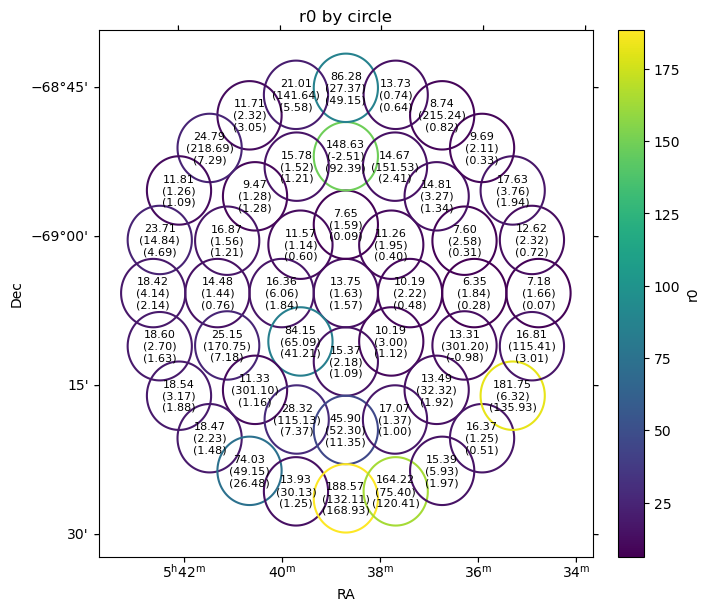

In [20]:
fig = plt.figure(figsize=(7, 6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

# anchor the WCS plot with the circle centers
ra_vals  = [item["ra_deg"] for item in circles]
dec_vals = [item["dec_deg"] for item in circles]

ax.scatter(
    ra_vals,
    dec_vals,
    s=1.0,
    color="white",
    alpha=0.01,
    transform=ax.get_transform("world")
)

r0_main = [dfs_fit[item["name"]]["r0"].iloc[0] for item in circles]

norm = mpl.colors.Normalize(vmin=min(r0_main), vmax=max(r0_main))
cmap = plt.cm.viridis

for item in circles:
    name = item["name"]
    df_fit = dfs_fit[name]

    vals = df_fit["r0"].tolist()[:3]
    txt = f"{vals[0]:.2f}\n({vals[1]:.2f})\n({vals[2]:.2f})"

    color = cmap(norm(vals[0]))

    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor=color,
        facecolor="none",
        linewidth=1.5,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

    ax.text(
        item["ra_deg"],
        item["dec_deg"],
        txt,
        transform=ax.get_transform("world"),
        ha="center",
        va="center",
        fontsize=8,
        color="black"
    )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("r0 by circle")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("r0")

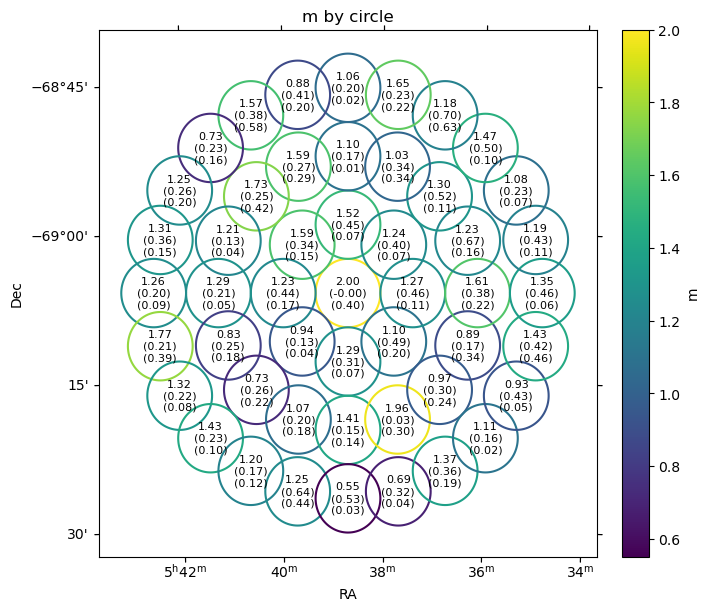

In [21]:
fig = plt.figure(figsize=(7, 6), constrained_layout=True)
ax = fig.add_subplot(1, 1, 1, projection=wcs)

# anchor the WCS plot with the circle centers
ra_vals  = [item["ra_deg"] for item in circles]
dec_vals = [item["dec_deg"] for item in circles]

ax.scatter(
    ra_vals,
    dec_vals,
    s=1.0,
    color="white",
    alpha=0.01,
    transform=ax.get_transform("world")
)

m_main = [dfs_fit[item["name"]]["m"].iloc[0] for item in circles]

norm = mpl.colors.Normalize(vmin=min(m_main), vmax=max(m_main))
cmap = plt.cm.viridis

for item in circles:
    name = item["name"]
    df_fit = dfs_fit[name]

    vals = df_fit["m"].tolist()[:3]
    txt = f"{vals[0]:.2f}\n({vals[1]:.2f})\n({vals[2]:.2f})"

    color = cmap(norm(vals[0]))

    circle = SphericalCircle(
        (item["center"].ra, item["center"].dec),
        item["radius_arcsec"] * u.arcsec,
        edgecolor=color,
        facecolor="none",
        linewidth=1.5,
        transform=ax.get_transform("world")
    )
    ax.add_patch(circle)

    ax.text(
        item["ra_deg"],
        item["dec_deg"],
        txt,
        transform=ax.get_transform("world"),
        ha="center",
        va="center",
        fontsize=8,
        color="black"
    )

ax.set_xlabel("RA")
ax.set_ylabel("Dec")
ax.set_title("m by circle")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax)
cbar.set_label("m")

In [22]:
import numpy as np
import pandas as pd

rows = []

for item in circles:
    name = item["name"]
    df_fit = dfs_fit[name]

    sig2_main = df_fit["sig2"].iloc[0]
    sig_main = np.sqrt(sig2_main)

    rows.append({
        "name": name,
        "label": item["label"],
        "ring": item["ring"],
        "angle_deg": item["angle_deg"],
        "sig2": sig2_main,
        "sig": sig_main,
        "r0": df_fit["r0"].iloc[0],
        "m": df_fit["m"].iloc[0],
    })

results_df = pd.DataFrame(rows)
results_df

,name,label,ring,angle_deg,sig2,sig,r0,m
0,LVM-30Dor-6563_C0,C0,center,NaN,209.525216,14.474986,13.746573,2.000000
1,LVM-30Dor-6563_I1,I1,inner,0.0,35.236001,5.935992,7.647870,1.522903
2,LVM-30Dor-6563_I2,I2,inner,45.0,17.889515,4.229600,11.569502,1.587845
3,LVM-30Dor-6563_I3,I3,inner,90.0,62.177260,7.885256,16.361588,1.234621
4,LVM-30Dor-6563_I4,I4,inner,135.0,191.473573,13.837398,84.151501,0.943994
5,LVM-30Dor-6563_I5,I5,inner,180.0,27.268388,5.221914,15.369323,1.289137
6,LVM-30Dor-6563_I6,I6,inner,225.0,20.611843,4.540027,10.194750,1.101435
7,LVM-30Dor-6563_I7,I7,inner,270.0,31.338650,5.598093,10.187210,1.272423
8,LVM-30Dor-6563_I8,I8,inner,315.0,57.863140,7.606782,11.258784,1.239924
9,LVM-30Dor-6563_M1,M1,middle,0.0,130.895698,11.440966,148.634423,1.096552


# Ring radius

sig

In [23]:
ring_stats = (
    results_df
    .groupby("ring")["sig"]
    .agg(["count", "mean", "std", "median"])
    .reset_index()
)

ring_stats

,ring,count,mean,std,median
0,center,1,14.474986,NaN,14.474986
1,inner,8,6.856883,3.110435,5.767043
2,middle,16,6.285142,2.747718,5.326691
3,outer,24,8.163804,4.982694,6.867845


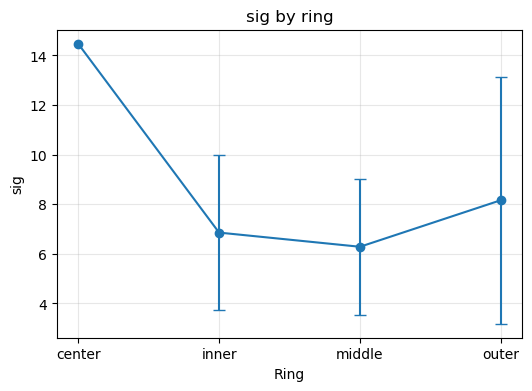

In [24]:
import matplotlib.pyplot as plt

ring_order = ["center", "inner", "middle", "outer"]
ring_stats["ring"] = pd.Categorical(ring_stats["ring"], categories=ring_order, ordered=True)
ring_stats = ring_stats.sort_values("ring")

fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    ring_stats["ring"],
    ring_stats["mean"],
    yerr=ring_stats["std"],
    fmt="o-",
    capsize=4
)

ax.set_xlabel("Ring")
ax.set_ylabel("sig")
ax.set_title("sig by ring")
ax.grid(True, alpha=0.3)

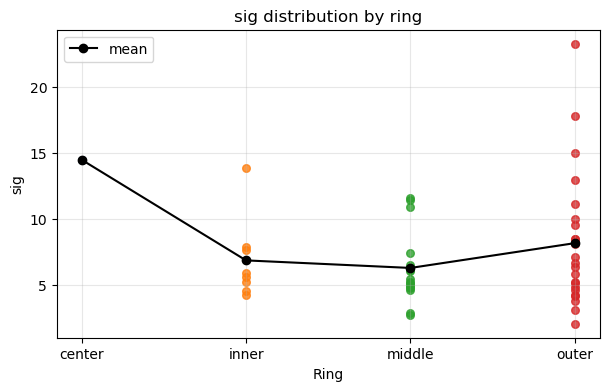

In [25]:
fig, ax = plt.subplots(figsize=(7, 4))

for i, ring in enumerate(ring_order):
    vals = results_df.loc[results_df["ring"] == ring, "sig"].values
    x = np.full(len(vals), i)
    ax.scatter(x, vals, s=30, alpha=0.8)

ax.plot(
    range(len(ring_stats)),
    ring_stats["mean"],
    color="black",
    marker="o",
    linewidth=1.5,
    label="mean"
)

ax.set_xticks(range(len(ring_order)))
ax.set_xticklabels(ring_order)
ax.set_xlabel("Ring")
ax.set_ylabel("sig")
ax.set_title("sig distribution by ring")
ax.grid(True, alpha=0.3)
ax.legend()

r0

In [26]:
ring_stats = (
    results_df
    .groupby("ring")["r0"]
    .agg(["count", "mean", "std", "median"])
    .reset_index()
)

ring_stats

,ring,count,mean,std,median
0,center,1,13.746573,NaN,13.746573
1,inner,8,20.842566,25.737433,11.414143
2,middle,16,25.201443,34.269541,14.743984
3,outer,24,41.416417,56.122377,18.026204


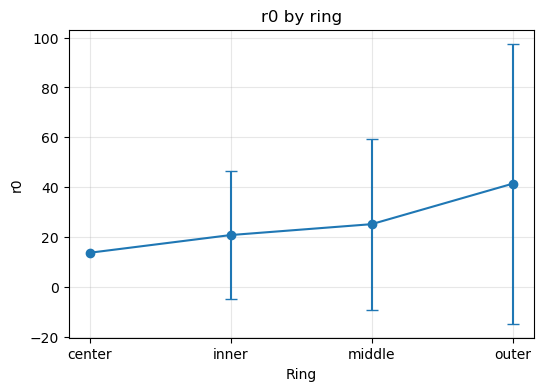

In [27]:
import matplotlib.pyplot as plt

ring_order = ["center", "inner", "middle", "outer"]
ring_stats["ring"] = pd.Categorical(ring_stats["ring"], categories=ring_order, ordered=True)
ring_stats = ring_stats.sort_values("ring")

fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    ring_stats["ring"],
    ring_stats["mean"],
    yerr=ring_stats["std"],
    fmt="o-",
    capsize=4
)

ax.set_xlabel("Ring")
ax.set_ylabel("r0")
ax.set_title("r0 by ring")
ax.grid(True, alpha=0.3)

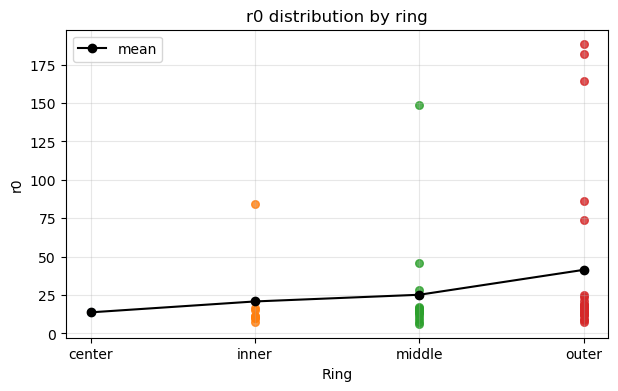

In [28]:
fig, ax = plt.subplots(figsize=(7, 4))

for i, ring in enumerate(ring_order):
    vals = results_df.loc[results_df["ring"] == ring, "r0"].values
    x = np.full(len(vals), i)
    ax.scatter(x, vals, s=30, alpha=0.8)

ax.plot(
    range(len(ring_stats)),
    ring_stats["mean"],
    color="black",
    marker="o",
    linewidth=1.5,
    label="mean"
)

ax.set_xticks(range(len(ring_order)))
ax.set_xticklabels(ring_order)
ax.set_xlabel("Ring")
ax.set_ylabel("r0")
ax.set_title("r0 distribution by ring")
ax.grid(True, alpha=0.3)
ax.legend()

m

In [29]:
ring_stats = (
    results_df
    .groupby("ring")["m"]
    .agg(["count", "mean", "std", "median"])
    .reset_index()
)

ring_stats

,ring,count,mean,std,median
0,center,1,2.000000,NaN,2.000000
1,inner,8,1.274035,0.207735,1.256174
2,middle,16,1.246452,0.344348,1.220464
3,outer,24,1.208931,0.298115,1.246699


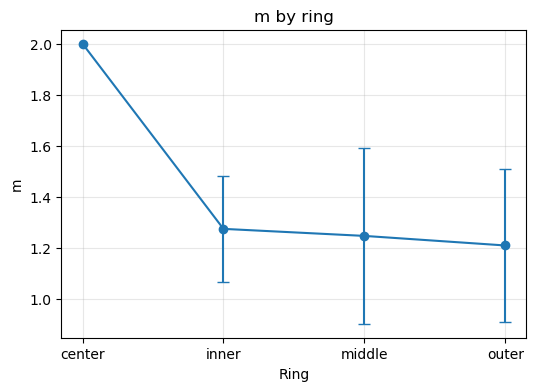

In [30]:
import matplotlib.pyplot as plt

ring_order = ["center", "inner", "middle", "outer"]
ring_stats["ring"] = pd.Categorical(ring_stats["ring"], categories=ring_order, ordered=True)
ring_stats = ring_stats.sort_values("ring")

fig, ax = plt.subplots(figsize=(6, 4))

ax.errorbar(
    ring_stats["ring"],
    ring_stats["mean"],
    yerr=ring_stats["std"],
    fmt="o-",
    capsize=4
)

ax.set_xlabel("Ring")
ax.set_ylabel("m")
ax.set_title("m by ring")
ax.grid(True, alpha=0.3)

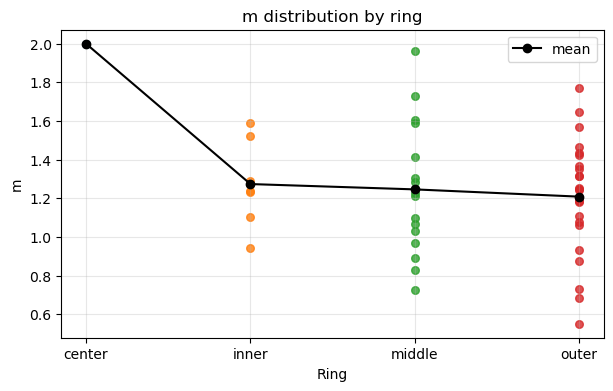

In [31]:
fig, ax = plt.subplots(figsize=(7, 4))

for i, ring in enumerate(ring_order):
    vals = results_df.loc[results_df["ring"] == ring, "m"].values
    x = np.full(len(vals), i)
    ax.scatter(x, vals, s=30, alpha=0.8)

ax.plot(
    range(len(ring_stats)),
    ring_stats["mean"],
    color="black",
    marker="o",
    linewidth=1.5,
    label="mean"
)

ax.set_xticks(range(len(ring_order)))
ax.set_xticklabels(ring_order)
ax.set_xlabel("Ring")
ax.set_ylabel("m")
ax.set_title("m distribution by ring")
ax.grid(True, alpha=0.3)
ax.legend()

# Physical radius

In [32]:
import numpy as np
import pandas as pd
import astropy.units as u

r_arcsec = radius.to(u.arcsec).value

ring_to_dist_pc = {
    "center": 0.0,
    "inner": 2 * r_arcsec * pc,
    "middle": 4 * r_arcsec * pc,
    "outer": 6 * r_arcsec * pc,
}

rows = []

for item in circles:
    name = item["name"]
    df_fit = dfs_fit[name]

    sig2_main = df_fit["sig2"].iloc[0]
    sig_main = np.sqrt(sig2_main)

    rows.append({
        "name": name,
        "label": item["label"],
        "ring": item["ring"],
        "angle_deg": item["angle_deg"],
        "radius_pc": ring_to_dist_pc[item["ring"]],
        "sig2": sig2_main,
        "sig": sig_main,
        "r0": df_fit["r0"].iloc[0],
        "m": df_fit["m"].iloc[0],
    })

results_df = pd.DataFrame(rows)

NameError: name 'radius' is not defined